# Autoencoders

Los **autoencoders** forman parte de la última parte de **visión por computador** que veremos en este curso.

Un **autoencoder** es un modelo que toma como entrada una imagen y produce como salida **la misma imagen**. Fíjate, por tanto, que los datos de entrada son justamente las etiquetas del modelo.

Los **autoencoders** son muy útiles porque permiten entrenar la red para obtener la **matriz de características** de un conjunto de datos determinado, y después convertirla de nuevo en una imagen. Si bien es cierto que, como tal, un **autoencoder** pudiera parecer inútil, piensa que después puede _dividirse_ el modelo en **encoder** y **decoder**, pudiendo combinar varias partes de ellos. Esto tiene varias aplicaciones y puede crear, entre otros:
- Modelos de eliminación de ruido
- Modelos de hiperresolución
- Modelos de coloración
- ...

Y, usando lo que veremos en los futuros cuadernillos:
- Modelos de descripción de imágenes
- Modelos de creación de imágenes
- Modelos de análisis de audio
- ...

En definitiva, entender los **autoencoders** es fundamental para poder continuar con la segunda parte del tema y, por ello, los veremos durante este cuadernillo ```405```.

# Un autoencoder básico

## Creando el dataset

Durante este problema trabajaremos con el _dataset_ **MNIST**, que recoge imágenes de dígitos manuscritos.

Durante este cuadernillo no usaremos ```FastAI```, dado que necesitamos crear un modelo un tanto peculiar. En su defecto, construiremos el modelo desde cero usando [```Keras```](https://keras.io/) y [```tensorflow```](https://www.tensorflow.org/?hl=es-419).

El hecho de tener que crear _a mano_ el modelo complica bastante este cuadernillo: no solo se debe saber qué se quiere obtener, sino también cómo se definen las capas convolucionales de una CNN. Consulta cualquier duda que tengas e intenta entender todas las celdas de este cuadernillo.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# normalización: de [0, 255] a [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# empaquetación del conjunto de train y test (que estaba aplanado)
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

## Creando el **autoencoder**

Vamos a crear un modelo _a mano_. Para ello, vamos a necesitar aplicar todos los conceptos que usábamos en ```401``` (capas de _pooling_, _convoluciones_, _activación_, etcétera).

Lo primero que vamos a crear es la entrada del modelo. En este caso, vamos a recibir una imagen que tendrá un tamaño de 28 x 28 (ten en cuenta que tenemos una dimensión extra, que por ahora ignoraremos --existe por compatibilidad--).

In [ ]:
model_input = layers.Input(shape=(28, 28, 1))

Ahora vamos a crear la parte del **codificador**.

Tras aplicar estas capas al _input_ recibido, el resultado debería ser el mapa de características.

Vamos a aplicar las siguientes capas:
- Capa convolucional de 32 filtros, con un kernel 3x3; seguida de una capa de activación RELU y aplicando _padding_ si es necesario.
- Capa de _pooling_, con un kernel 2x2 y aplicando _padding_ si es necesario.
- Capa convolucional de 32 filtros, con un kernel 3x3; seguida de una capa de activación RELU y aplicando _padding_ si es necesario.
- Capa de _pooling_, con un kernel 2x2 y aplicando _padding_ si es necesario.

Fíjate cómo se van redefiniendo las capas, tomando como _input_ ```capa(output)``` el _output_ de la capa anterior.

In [ ]:
# primera capa
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(model_input)

# segunda capa
x = layers.MaxPooling2D((2, 2), padding='same')(x)

# tercera capa
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)

# cuarta capa
encoder = layers.MaxPooling2D((2, 2), padding='same')(x)

¿Qué pinta tendrá nuestra matriz de características?

- ---
- La entrada tendrá tamaño (28, 28, 1).
- ---
- La primera capa convolucional necesitará _padding_, porque aplica un kernel 3x3, pero 28 no es múltiplo de 3. Tras aplicar el _padding_ quedará (29, 29, 1).
- Tras la primera capa convolucional, tendremos (28, 28, 32).
- ---
- Tras la primera capa de _pooling_ quedará (14, 14, 32).
- ---
- La segunda capa convolucional necesitará _padding_, dejando un (15, 15, 32).
- Tras la segunda capa convolucional, tendremos un (14, 14, 32).
- ---
- Tras la segunda capa de _pooling_ tendremos un (7, 7, 32), la salida del **encoder**.
- ---

Fíjate:
- Aplicar capas de convolución no reduce ni aumenta las dimensiones porque estamos usando _padding_.
- El _padding_ solo se aplica si las dimensiones no son múltiplo del kernel.
- El _pooling_ reduce las dimensiones según el tamaño del kernel. Un kernel $2 \cdot 2$ reduce a la mitad.

Una vez creado el **encoder**, vamos a crear un **decoder** que sea simétrico a éste. Las capas que vamos a aplicar serán, justamente, las inversas. Aquí usaremos capas de **upsampling**, que hacen lo contrario que las de _pooling_.

In [ ]:
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoder = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

Vamos a ver qué pinta van teniendo nuestros datos:

- ---
- La entrada es una matriz (7, 7, 32), que es justo la salida de nuestro **encoder**.
- ---
- Tras la primera capa de convolución tenemos un (7, 7, 32).
- ---
- Tras la primera capa de _upsampling_ tenemos un (14, 14, 32).
- ---
- Tras la segunda capa de convolución tenemos un (14, 14, 32).
- ---
- Tras la segunda capa de _upsampling_ tenemnos un (28, 28, 32).
- ---
- Tras la tercera capa de convolución tenemos un (28, 28, 1).
- ---

Fíjate en cómo se eliminan los filtros después de la última capa convolucional. Además, aplicamos una activación sigmoide en vez de una RELU para tener valores en el rango $[0, 1]$.

Ahora vamos a compilar nuestro modelo. Este paso consiste en unir todas las capas que hemos definido previamente. Necesitamos indicar la entrada del modelo y la capa final. Además, vamos a indicar que usaremos el optimizador ```Adam``` de parámetros (que lo hemos usado de forma implícita en todos nuestros modelos anteriores) y la función de pérdida de ```BinaryCrossEntropy```.

In [ ]:
autoencoder = keras.Model(model_input, decoder)
autoencoder.compile(optimizer = "adam", loss = "binary_crossentropy")

Podemos ver el resumen de nuestro modelo con la función ```summary```.

In [ ]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento del modelo

Ahora podemos entrenar nuestro modelo con la función ```fit``` (que, por cierto, también existe para los ```Learner``` de ```Fastai```)

In [ ]:
autoencoder.fit(
  x_train, # datos de entrenamiento
  x_train, # etiquetas (en este caso imágenes enteras, que son justamente la entrada)
  epochs = 20, # épocas de entrenamiento
  batch_size = 128, # tamaño del lote (batch)
  validation_data = (x_test, x_test) # datos de validación (imagen, etiqueta)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 0.1983 - val_loss: 0.0769
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0759 - val_loss: 0.0721
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0724 - val_loss: 0.0703
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0707 - val_loss: 0.0691
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0696 - val_loss: 0.0683
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0687 - val_loss: 0.0677
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0682 - val_loss: 0.0674
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0676 - val_loss: 0.0668
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0673 - val_loss: 0.0664
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0668 - val_loss: 0.0660
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0665 - val_loss: 0.0661
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/st

Ahora vamos a mostrar algún resultado, para que veas lo que hemos hecho:

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


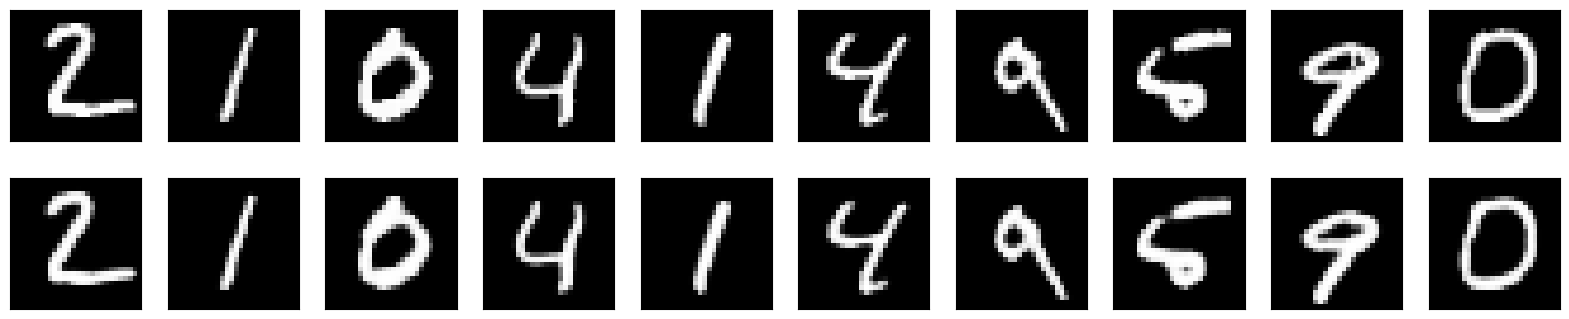

In [ ]:
decoded_imgs = autoencoder.predict(x_test) # predigo el conjunto de test

plt.figure(figsize=(20, 4)) # creo una imagen para ver mejor los resultados
for i in range(1, 10 + 1): # mostraré 9 imágenes
    ax = plt.subplot(2, 10, i)
    plt.imshow(x_test[i].reshape(28, 28)) # muestro el dato real (primera fila)
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, 10, i + 10)
    plt.imshow(decoded_imgs[i].reshape(28, 28)) # muestro el dato predicho (segunda fila)
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

# Modelos de eliminación de ruido

El ruido en las imágenes son píxeles que _embadurnan_ la imagen en su conjunto.

Es muy común que estos píxeles existan en imágenes que necesitan una alta precisión o que hacen fotografías a objetos muy, muy lejanos (como las fotografías realizadas por el [telescopio espacial Hubble](https://es.wikipedia.org/wiki/Telescopio_espacial_Hubble).

Para poder procesar y tratar las imágenes que tienen ruido es necesario eliminarlo y, en ese proceso, los autoencoders pueden jugar un papel fundamental.

Evidentemente, para entrenar un autoencoder para eliminar ruido necesitaremos imágenes limpias y con ruido (es un proceso de aprendizaje automático supervisado). En este caso, vamos a generar nosotros ruido (blanco o gausiano) sobre las imágenes del MNIST.

Para ello, usaremos la función ```normal``` que genera ruido gausiano. Creamos tanto ruido como tamaño tengan nuestros conjuntos de entrenamiento y test, modificando las imágenes originales y creando otros _dataset_ paralelos.

In [ ]:
noise_factor = 0.5

# creación de los datasets con ruido
x_train_noisy = x_train + noise_factor * np.random.normal(loc = 0.0, scale = 1.0, size = x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# eliminación de valores por debajo de 0 y por encima de 1 (los menores que 0 se convierten en 0; los mayores de 1 en 1)
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

Básicamente, hemos hecho esto:

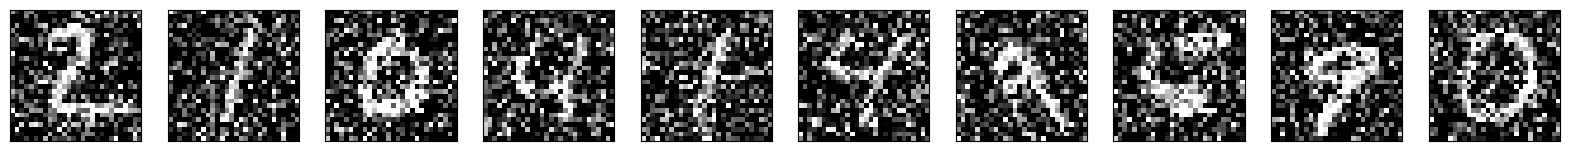

In [ ]:
plt.figure(figsize=(20, 2))
for i in range(1, 10 + 1):
    ax = plt.subplot(1, 10, i)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

El autoencoder que hemos creado de forma manual anteriormente puede servinos para resolver este problema. Creamos un modelo a partir de esa estructura de capas.

In [ ]:
autoencoder_noise = keras.Model(model_input, decoder)
autoencoder_noise.compile(optimizer = "adam", loss = "binary_crossentropy")

Y, finalmente, podemos entrenarlo.

Fíjate en cómo modificamos las etiquetas. Ahora le pedimos que la entrada tenga ruido, pero la etiqueta **NO** lo tenga.

In [ ]:
autoencoder_noise.fit(
  x_train_noisy, # datos de entrenamiento
  x_train, # etiquetas (la versión SIN ruido de la imagen)
  epochs = 40, # épocas de entrenamiento (pongo más porque es una tarea más compleja)
  batch_size = 128,
  validation_data = (x_test_noisy, x_test) # datos de validación (imagen con ruido, etiqueta sin ruido)
)

Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.1241 - val_loss: 0.1054
Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1054 - val_loss: 0.1027
Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1031 - val_loss: 0.1013
Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1019 - val_loss: 0.1003
Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1007 - val_loss: 0.1003
Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0999 - val_loss: 0.0985
Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0994 - val_loss: 0.0979
Epoch 8/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0987 - val_loss: 0.0975
Epoch 9/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0982 - val_loss: 0.0971
Epoch 10/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0977 - val_loss: 0.0967
Epoch 11/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0974 - val_loss: 0.0963
Epoch 12/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/ste

Y, como antes, podemos ver un ejemplo:

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


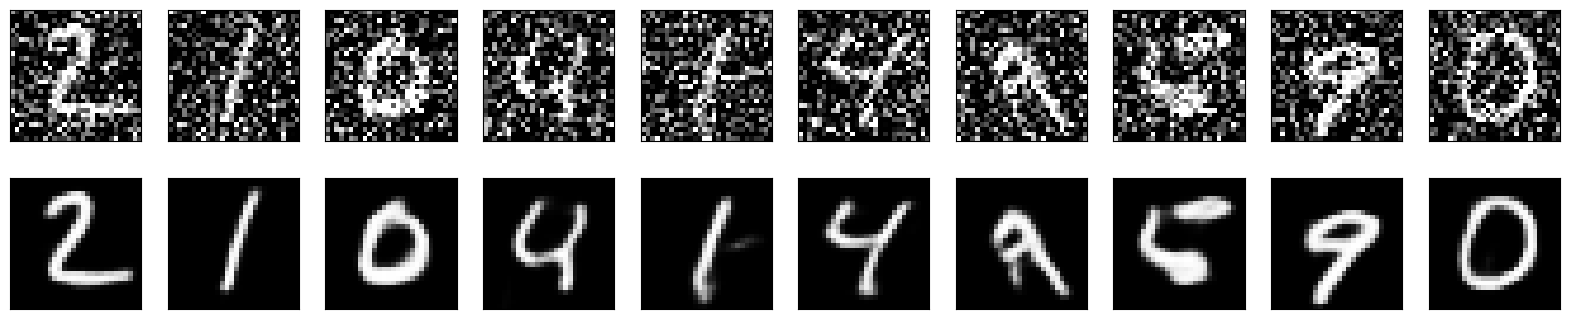

In [ ]:
decoded_imgs_noise = autoencoder_noise.predict(x_test_noisy) # predigo el conjunto de test

plt.figure(figsize=(20, 4)) # creo una imagen para ver mejor los resultados
for i in range(1, 10 + 1): # mostraré 9 imágenes
    ax = plt.subplot(2, 10, i)
    plt.imshow(x_test_noisy[i].reshape(28, 28)) # muestro el dato real (primera fila)
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, 10, i + 10)
    plt.imshow(decoded_imgs_noise[i].reshape(28, 28)) # muestro el dato predicho (segunda fila)
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

# Resumen

Durante este cuadernillo hemos visto cómo crear **autoencoders**, que son básicos para comprender cómo funcionan los modelos más complejos de la **visión por computador**.

Crear otro tipo de **autoencoders**, a partir de este ejemplo, es bastante sencillo: la idea principal es que tomamos una imagen como entrada y producimos la misma imagen (o con alguna variación geométrica) como salida.

Por ejemplo, para construir un modelo de hiperresolución, aumentaríamos en 1 las capas de nuestro decoder, haciendo que las salidas fuesen de 56 x 56 en vez de 28 x 28.

Para construir un modelo de coloración, entrenaríamos un **autoencoder** pasando como entrada la imagen en escala de grises y produciríamos la imagen en tres canales de color.

**Herramientas más potentes que puedes necesitar en el futuro, pero que se salen del curso**:
- [Este artículo científico](http://users.cecs.anu.edu.au/~Tom.Gedeon/conf/ABCs2018/paper/ABCs2018_paper_58.pdf) comenta la existencia de otros **autoencoders** (variational autoencoders) que trabajan con espacios subyacentes creados como si fuesen distribuciones, de forma que son más reutilizables al definir espacios completos. [Aquí se explica esta idea](https://www.cs.us.es/~fsancho/Blog/posts/VAE.md).
- Modelos del tipo GAN (_Generative Adversarial Networks_; [Redes Generativas Adversarias](https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=8253599)). Estas redes permiten crear dos modelos, uno generador y otro detector, que crean imágenes falsas pero verídicas.
- Modelos del tipo [CycleGAN](https://arxiv.org/pdf/1712.02950.pdf), que usan dos GAN para modificar pares de imágenes sin asociación previa. [Aquí un ejemplo](https://www.tensorflow.org/tutorials/generative/cyclegan?hl=es-419) desde el tutorial de ```tensorflow```.
- Modelos del tipo [modelos de difusión](https://en.wikipedia.org/wiki/Diffusion_model), que son la evolución de las GAN.